In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import re

In [3]:
from sklearn.decomposition import PCA


In [4]:
import joblib

# Load them later
data_pca = joblib.load('spiff_data_pca.pkl')

In [5]:
#read the complete dataset as compiled in read_spiff
data_df = pd.read_pickle('spiff_all.pkl')
diamondback_df = pd.read_pickle('spiff_diamondback.pkl')
atmo2020_df = pd.read_pickle('spiff_ATMO2020.pkl')

In [6]:
#data_norm_df = data_df / data_df.mean()
diamondback_norm_df = diamondback_df / diamondback_df.mean()
atmo2020_norm_df = atmo2020_df / atmo2020_df.mean()


In [7]:
# repeat removal of outliers...
# Calculate mean and std for each row (file)
row_means = data_df.mean(axis=0)
row_stds = data_df.std(axis=0)

# Define a threshold (e.g., 5 sigma)
threshold = 3
#
# Note: have experimented with this. 10 sigma is too big, the PCA components become spikes
#   5 seems okay for firs three components

# Mask points that are too far from the mean
# This keeps the shape of your data but hides the spikes
df_cleaned = data_df.mask((data_df - row_means).abs() > threshold * row_stds)

# Optional: Interpolate the now-missing spikes so PCA doesn't break
df_cleaned = df_cleaned.interpolate(axis=0).ffill().bfill()
#
column_means = df_cleaned.mean(axis=0)

# Divide each column by its own mean
# Result: Every column now has a mean of 1.0
df_normalized = df_cleaned/ column_means
# 
# we are doing the same thing above as in other notebook

In [8]:
X_data = df_normalized.T.copy()
X_diamondback = diamondback_norm_df.T.copy()
X_atmo2020 = atmo2020_norm_df.T.copy()

# 2. Fill NaNs
# Option A: Fill with 0
#X_filled = X.fillna(0) 
# Option B: Interpolate (better for spectra)
X_data_filled = X_data.interpolate(axis=1).fillna(0)

# 3. Standardize the data (Mean=0, Variance=1)
#scaler = StandardScaler()
# use the robust scaler
#scaler = RobustScaler()
#X_scaled = scaler.fit_transform(X_filled)
# all the scaling is not helpful for spectroscopic data. 
#
X_data_scaled=X_data_filled
X_diamondback_scaled = X_diamondback
X_atmo2020_scaled = X_atmo2020

In [9]:
diamondback_pca_features = data_pca.transform(X_diamondback_scaled)
data_pca_features = data_pca.transform(X_data_scaled)
atmo2020_pca_features = data_pca.transform(X_atmo2020_scaled)


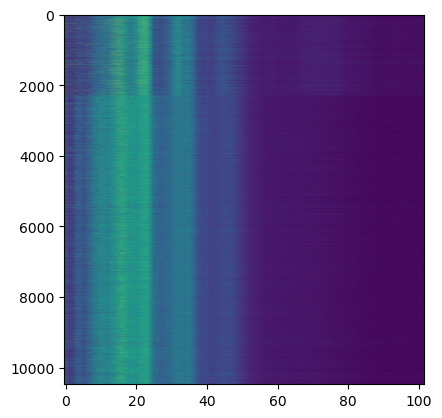

In [10]:
plt.imshow(X_data_scaled,aspect=0.01,vmin=0,vmax=5)


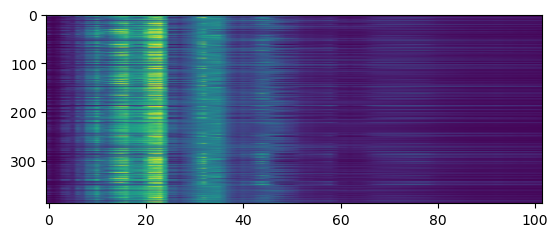

In [11]:
plt.imshow(X_diamondback_scaled,aspect=0.1,vmin=0,vmax=5)
#
# note tha models are not sorted in ny sensible way

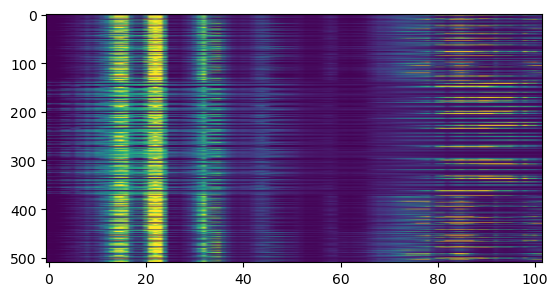

In [12]:
plt.imshow(X_atmo2020_scaled,aspect=0.1,vmin=0,vmax=5)
#
# note tha models are not sorted in ny sensible way

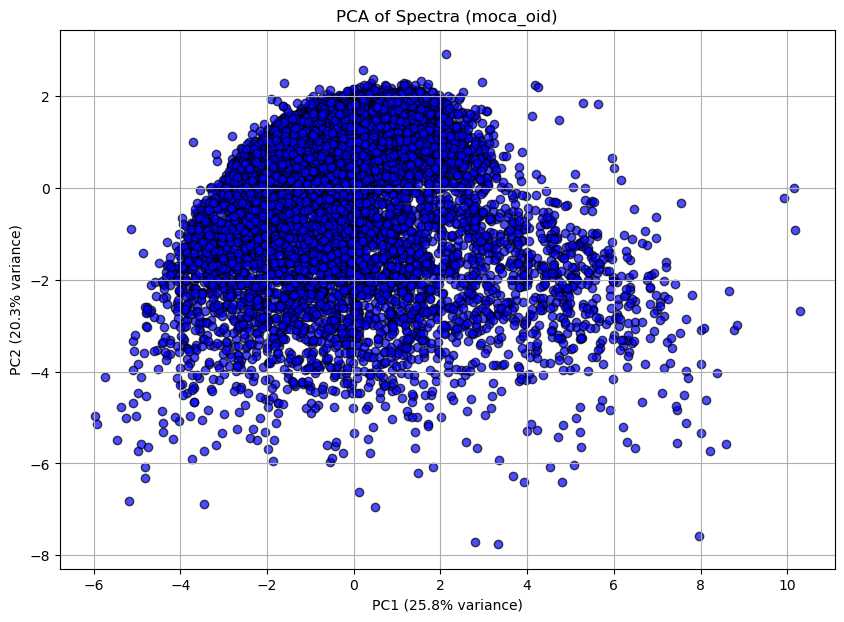

In [13]:
plt.figure(figsize=(10, 7))
plt.scatter(data_pca_features[:, 0], data_pca_features[:, 1], alpha=0.7, c='blue', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({data_pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
# we didn't clean the many-sigma outliers so it doesn't look the same. OOPS!
# 
# 
plt.grid(True)
plt.show()

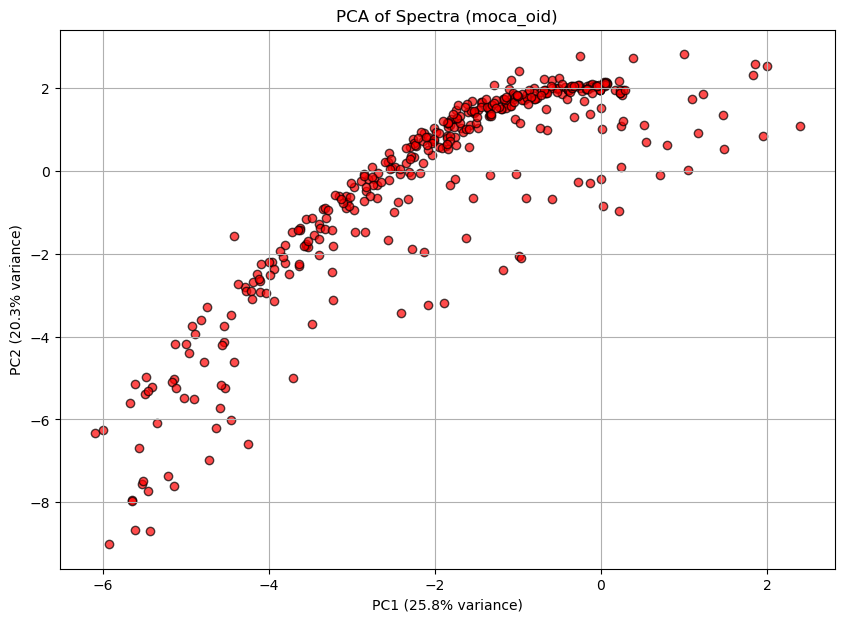

In [14]:
plt.figure(figsize=(10, 7))
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 1], alpha=0.7, c='red', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({data_pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
plt.grid(True)
plt.show()

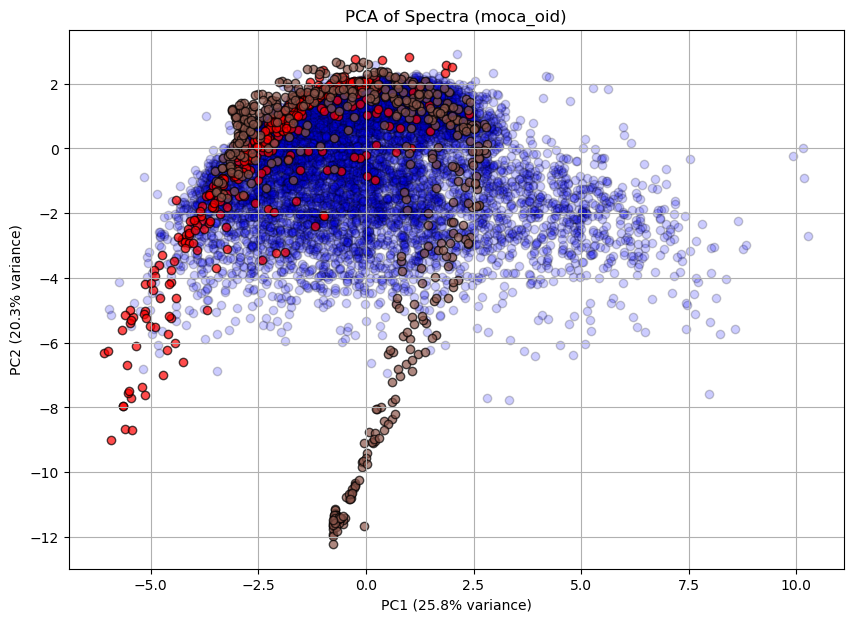

In [15]:
plt.figure(figsize=(10, 7))
plt.scatter(data_pca_features[:, 0], data_pca_features[:, 1], alpha=0.2, c='blue', edgecolors='k')
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 1], alpha=0.7, c='red', edgecolors='k')
plt.scatter(atmo2020_pca_features[:, 0], atmo2020_pca_features[:, 1], alpha=0.7, c='C5', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({data_pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
# 
# 
# 
plt.grid(True)
plt.show()

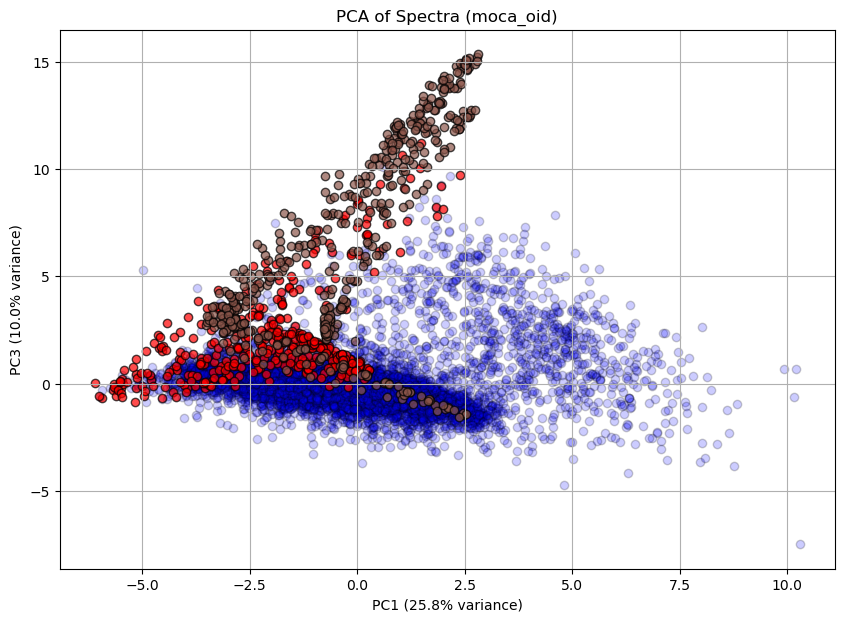

In [16]:
plt.figure(figsize=(10, 7))
plt.scatter(data_pca_features[:, 0], data_pca_features[:, 2], alpha=0.2, c='blue', edgecolors='k')
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 2], alpha=0.7, c='red', edgecolors='k')
plt.scatter(atmo2020_pca_features[:, 0], atmo2020_pca_features[:, 2], alpha=0.7, c='C5', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC3 ({data_pca.explained_variance_ratio_[2]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
# 
# 
# 
plt.grid(True)
plt.show()

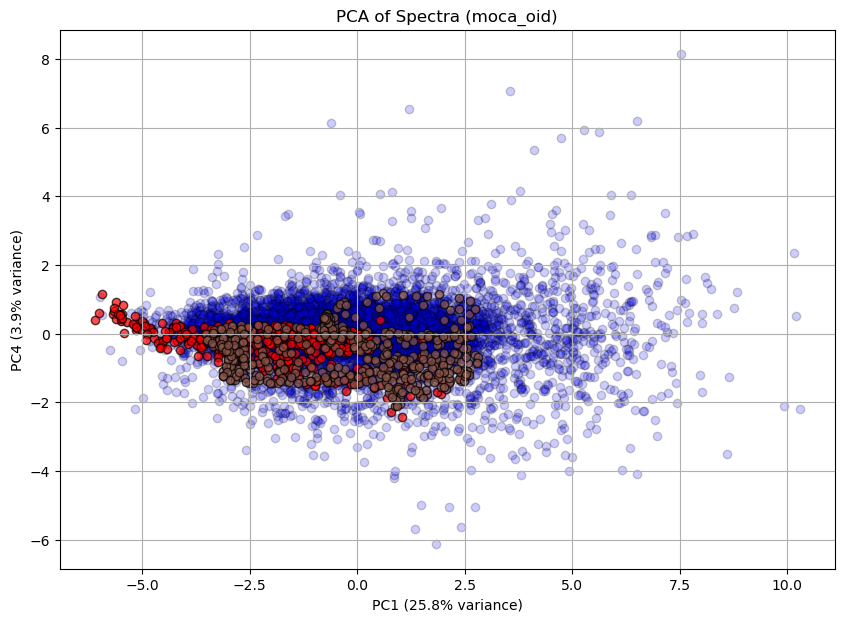

In [17]:
plt.figure(figsize=(10, 7))
plt.scatter(data_pca_features[:, 0], data_pca_features[:, 3], alpha=0.2, c='blue', edgecolors='k')
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 3], alpha=0.7, c='red', edgecolors='k')
plt.scatter(atmo2020_pca_features[:, 0], atmo2020_pca_features[:, 3], alpha=0.7, c='C5', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC4 ({data_pca.explained_variance_ratio_[3]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
# 
# 
# 
plt.grid(True)
plt.show()

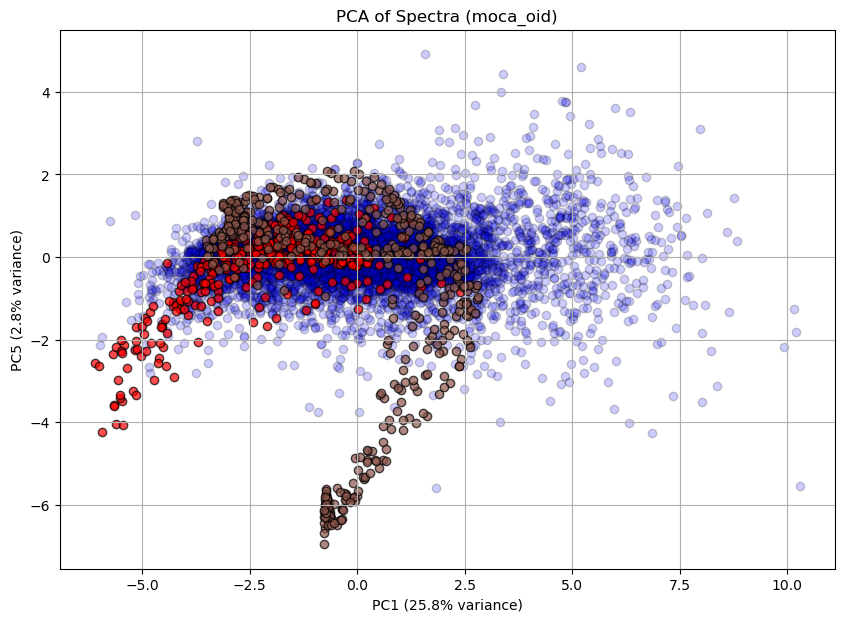

In [18]:
plt.figure(figsize=(10, 7))
plt.scatter(data_pca_features[:, 0], data_pca_features[:, 4], alpha=0.2, c='blue', edgecolors='k')
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 4], alpha=0.7, c='red', edgecolors='k')
plt.scatter(atmo2020_pca_features[:, 0], atmo2020_pca_features[:, 4], alpha=0.7, c='C5', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC5 ({data_pca.explained_variance_ratio_[4]:.1%} variance)')
plt.title('PCA of Spectra (moca_oid)')
# 
# 
# 
plt.grid(True)
plt.show()

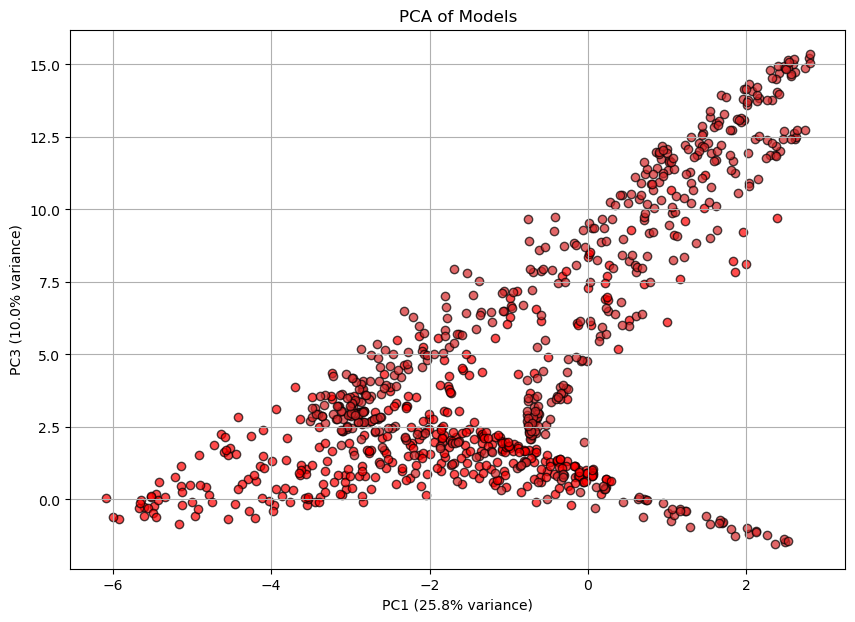

In [19]:
plt.figure(figsize=(10, 7))
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 2], alpha=0.7, c='red', edgecolors='k')
plt.scatter(atmo2020_pca_features[:, 0], atmo2020_pca_features[:, 2], alpha=0.7, c='C3', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC3 ({data_pca.explained_variance_ratio_[2]:.1%} variance)')
plt.title('PCA of Models')
plt.grid(True)
plt.show()

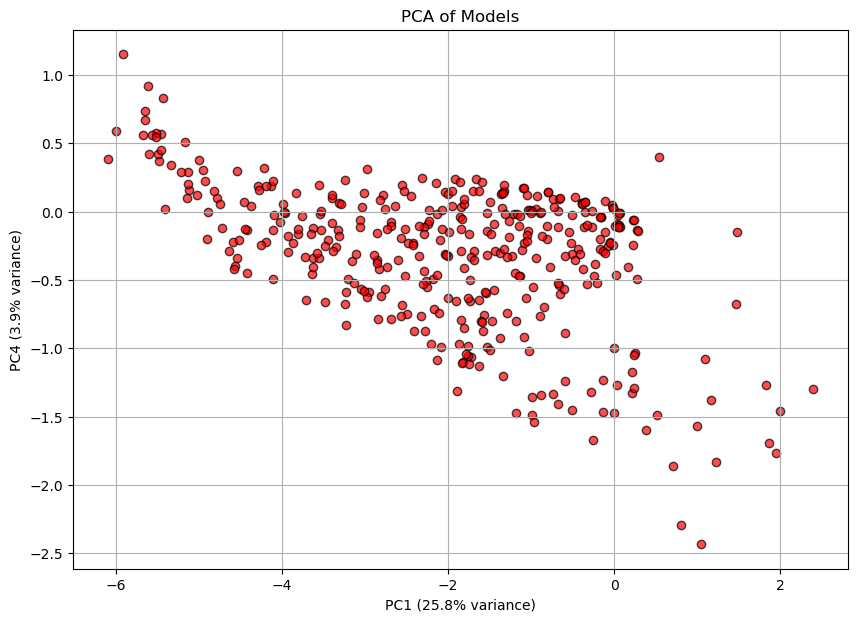

In [20]:
plt.figure(figsize=(10, 7))
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 3], alpha=0.7, c='red', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC4 ({data_pca.explained_variance_ratio_[3]:.1%} variance)')
plt.title('PCA of Models')
plt.grid(True)
plt.show()

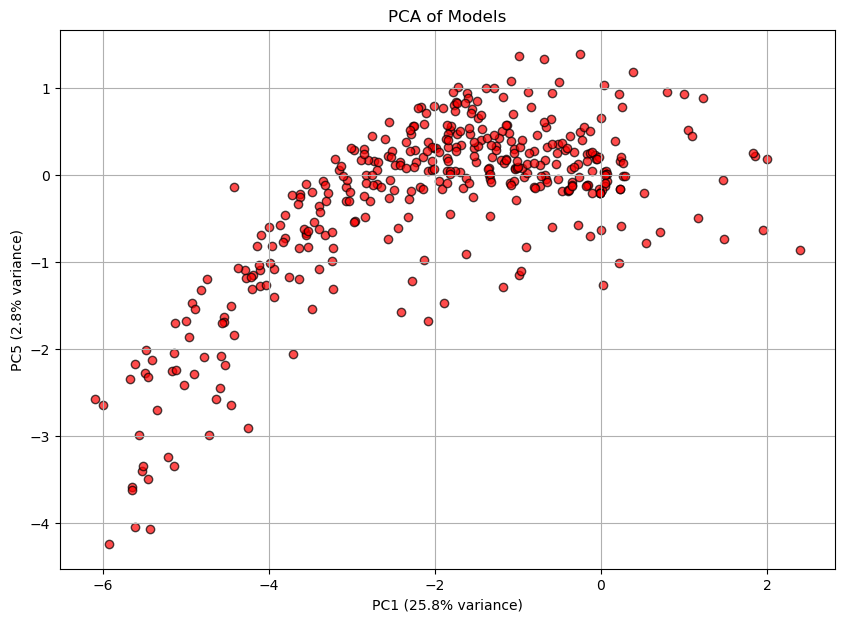

In [21]:
plt.figure(figsize=(10, 7))
plt.scatter(diamondback_pca_features[:, 0], diamondback_pca_features[:, 4], alpha=0.7, c='red', edgecolors='k')
plt.xlabel(f'PC1 ({data_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC5 ({data_pca.explained_variance_ratio_[4]:.1%} variance)')
plt.title('PCA of Models')
plt.grid(True)
plt.show()

In [22]:
#not really clear where I'm going with this....
#
# Remember the Sonora Diamondback models include parameters that are poor fits to the data 
#  such as extremely cloudy models; clear models for L dwarfs; cloudy models for T dwarfs 
#  but also go down onlu to 900K but data goes lower
#
# ATMO2020 lack clouds for warm L dwarfs but extend to lower temperatures
# including some that are cooler than any of the dataset